In [1]:
import os
import pandas as pd
import numpy as np

import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader

from torchvision import models
import matplotlib.pyplot as plt

from data.datasets import DeepFakeDataset

In [2]:
image_metadata_path = "Deepfake-Eval-2024/image-metadata-publish.csv"
image_dir_path = 'Deepfake-Eval-2024/image-data'

In [3]:
image_metadata_df = pd.read_csv(image_metadata_path)

In [4]:
image_metadata_df[image_metadata_df['Filename']=='#NAME?']

,Filename,Date,Ground Truth,Public Comments,Finetuning Set


In [5]:
image_metadata_df = image_metadata_df[image_metadata_df['Filename']!='#NAME?'].reset_index(drop=True)
image_metadata_df.to_csv(image_metadata_path, index = False)

In [6]:
data = DeepFakeDataset(image_metadata_path, image_dir_path)

In [7]:
dataloader = DataLoader(data, batch_size = 32, shuffle = True)

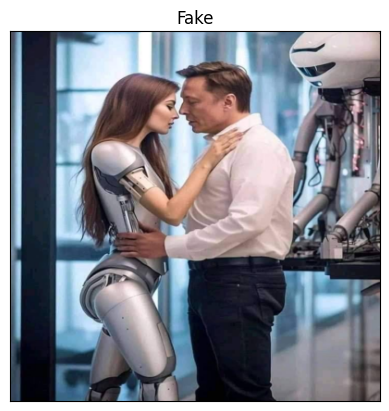

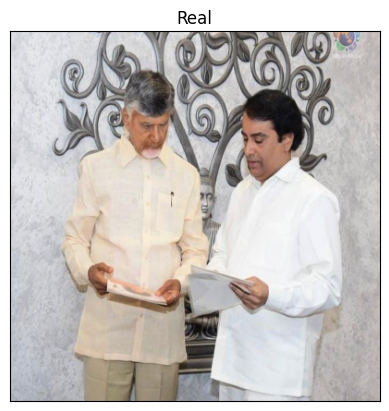

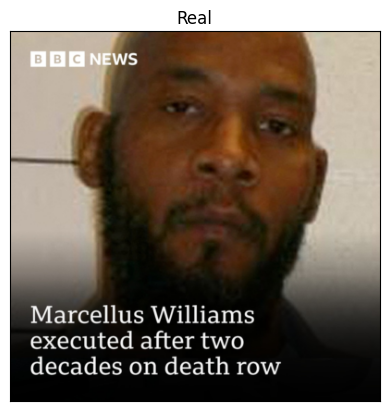

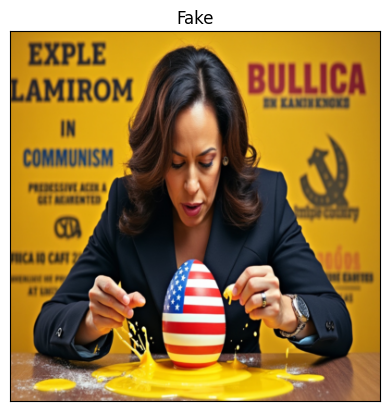

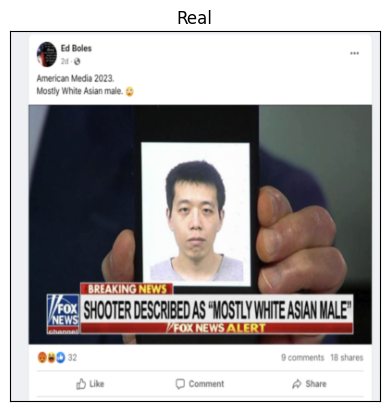

In [8]:
count = 0
features, label = next(iter(dataloader))
    # count += 1
    # if count < 5:
for i in range(5):
    img = features[i]
    plt.imshow(np.transpose(img, (1,2,0))) # convert pytorch tensor (3 channels, H, W) to numpy array (H, W, 3 channels)
    plt.title("Fake" if label[i] else "Real")
    plt.xticks([])
    plt.yticks([])
    plt.show()

In [9]:
model = torch.hub.load('pytorch/vision:v0.10.0', 'resnet50', weights="ResNet50_Weights.IMAGENET1K_V1")
model.fc = nn.Identity()    # replace classification head with passthrough effectively removing last classification layer

Using cache found in /home/azureuser/.cache/torch/hub/pytorch_vision_v0.10.0


In [10]:
# extract features for train
resnet_features = model(features)

In [11]:
resnet_features.shape

torch.Size([32, 2048])